EDA (Analyse Exploratoire des Données)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage inline
%matplotlib inline
sns.set_style("whitegrid")

print("✅ Libraries importées avec succès")

✅ Libraries importées avec succès


In [5]:
df = pd.read_csv('../data/Loan_Data.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [6]:
print("=== INFOS GÉNÉRALES ===")
print(df.info())
print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== INFOS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None

=== STATISTIQUES DESCRIPTIVES ===


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [7]:
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal valeurs manquantes : {missing.sum()}")

=== VALEURS MANQUANTES ===
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Total valeurs manquantes : 0


/var/folders/kl/2c0g6vmx6k3973crfzqsddgw0000gn/T/ipykernel_11376/3731438493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='default', data=df, palette=['#2ecc71', '#e74c3c'])


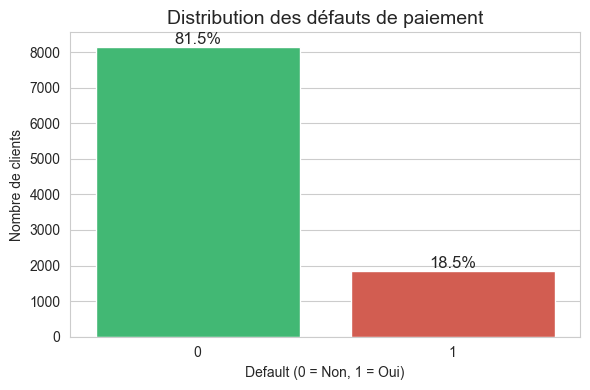

default
0    8149
1    1851
Name: count, dtype: int64

Taux de défaut : 18.51%


In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='default', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Distribution des défauts de paiement", fontsize=14)
plt.xlabel("Default (0 = Non, 1 = Oui)")
plt.ylabel("Nombre de clients")

# Afficher les pourcentages
total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('../data/target_distribution.png')
plt.show()

print(df['default'].value_counts())
print(f"\nTaux de défaut : {df['default'].mean()*100:.2f}%")

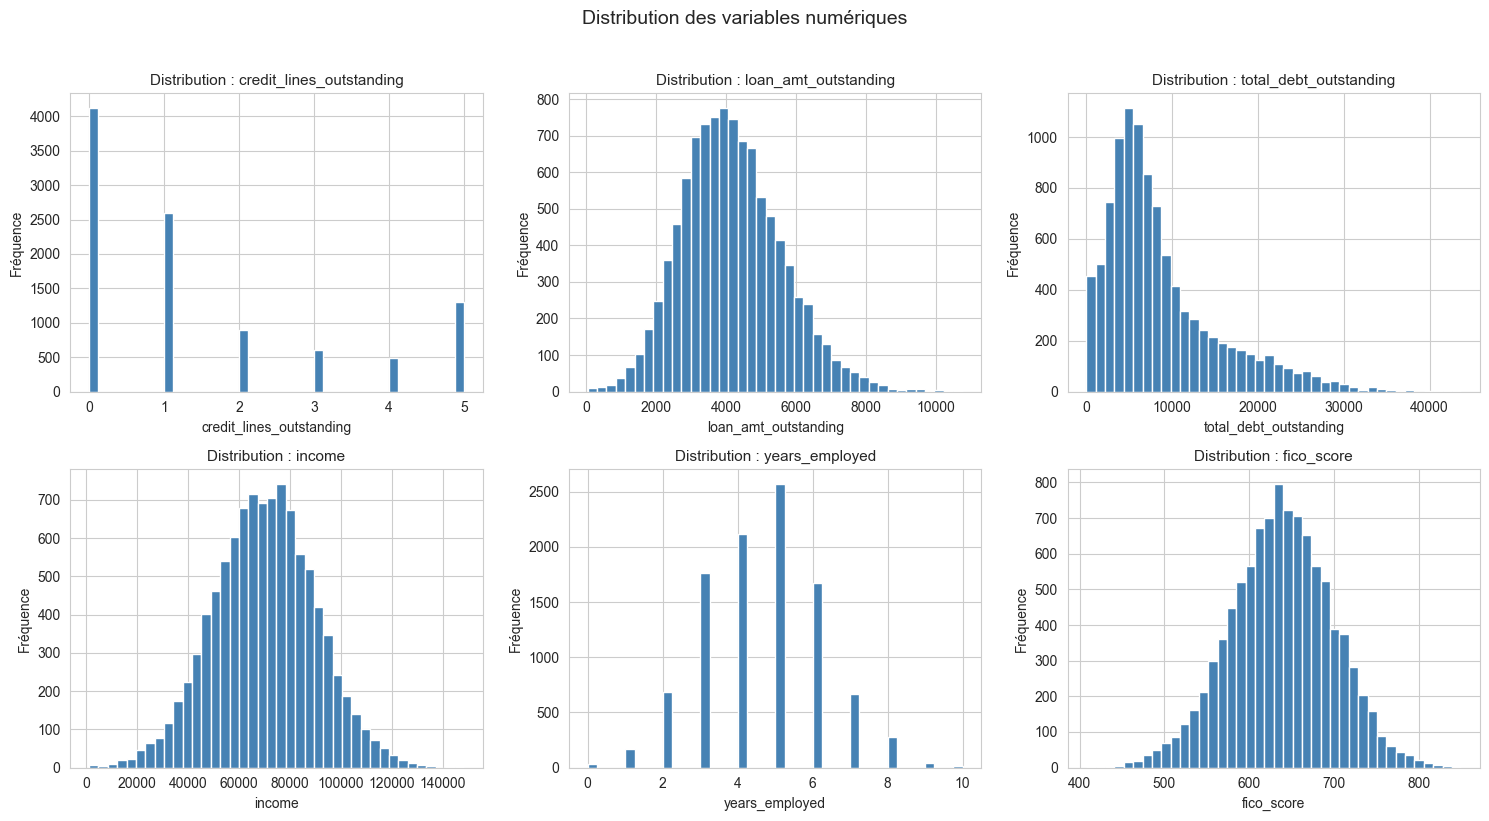

In [9]:
features = ['credit_lines_outstanding', 'loan_amt_outstanding', 
            'total_debt_outstanding', 'income', 
            'years_employed', 'fico_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution : {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Distribution des variables numériques", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/features_distribution.png')
plt.show()

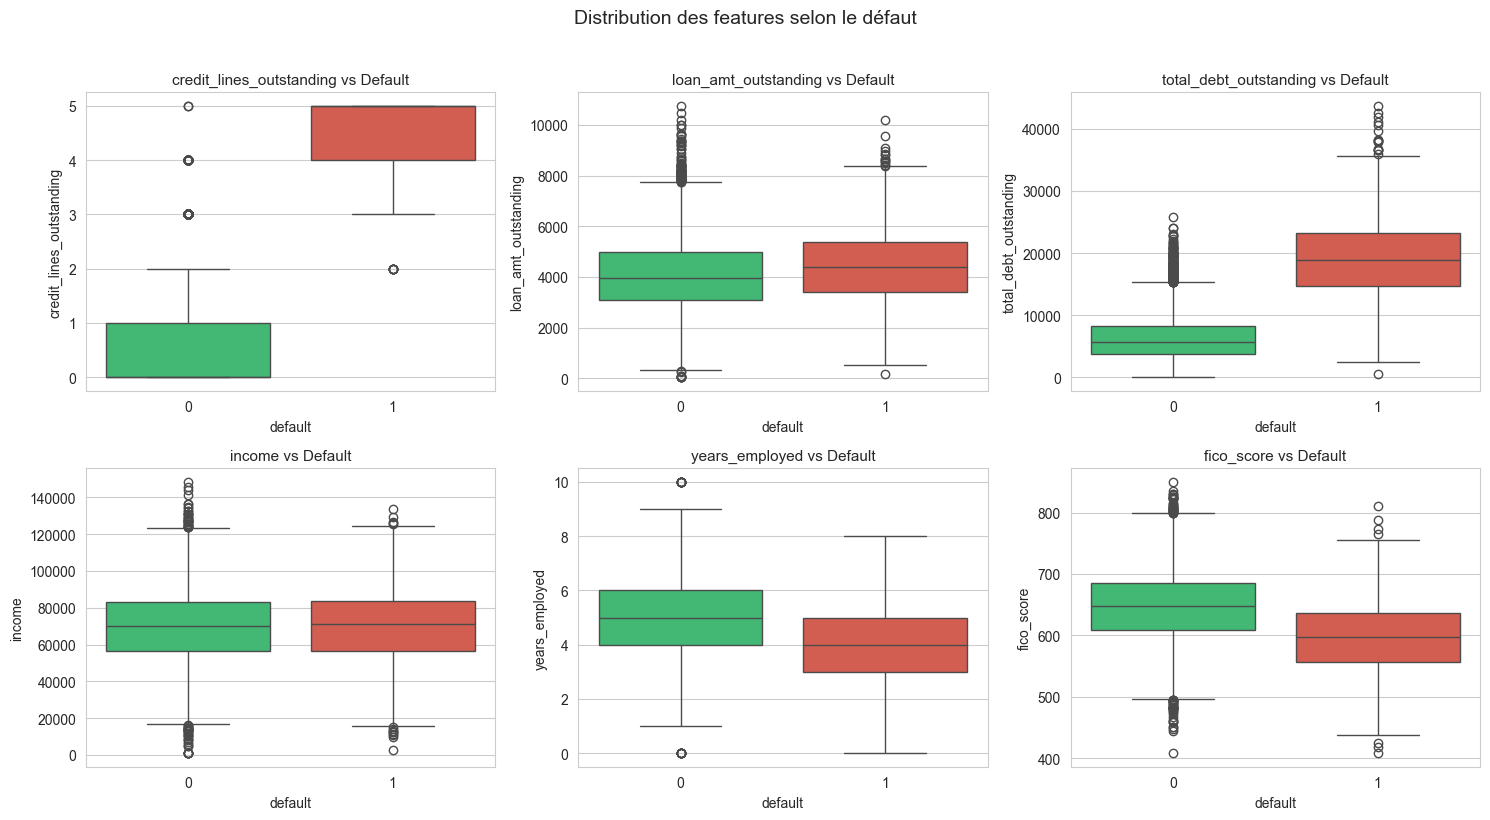

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='default', y=col, data=df, 
                hue='default',
                palette={0: '#2ecc71', 1: '#e74c3c'}, 
                legend=False,
                ax=axes[i])
    axes[i].set_title(f'{col} vs Default', fontsize=11)

plt.suptitle("Distribution des features selon le défaut", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/boxplots.png')
plt.show()

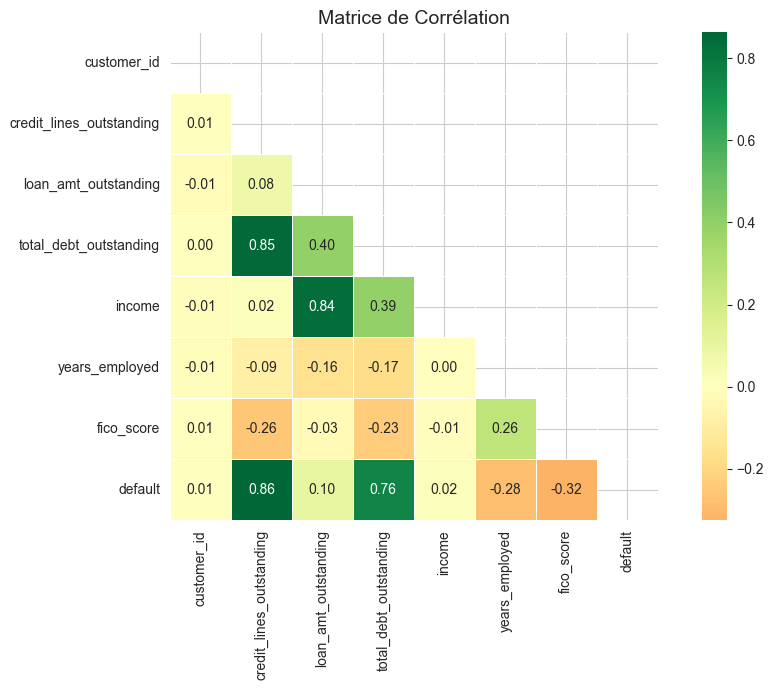

In [11]:
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)

plt.title("Matrice de Corrélation", fontsize=14)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png')
plt.show()

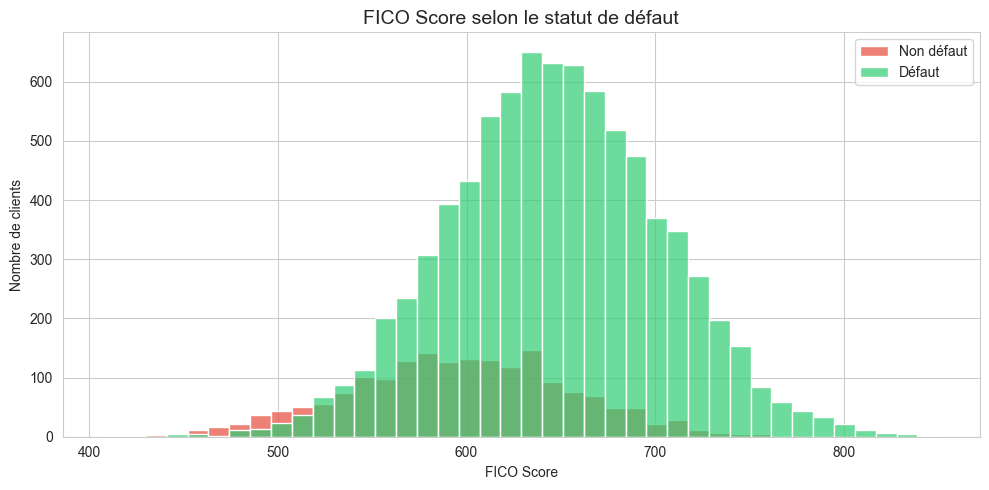

FICO Score moyen par statut de défaut :
default
0    646.938765
1    596.257699
Name: fico_score, dtype: float64


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='fico_score', hue='default', 
             bins=40, palette=['#2ecc71', '#e74c3c'],
             alpha=0.7)
plt.title("FICO Score selon le statut de défaut", fontsize=14)
plt.xlabel("FICO Score")
plt.ylabel("Nombre de clients")
plt.legend(["Non défaut", "Défaut"])
plt.tight_layout()
plt.savefig('../data/fico_vs_default.png')
plt.show()

print("FICO Score moyen par statut de défaut :")
print(df.groupby('default')['fico_score'].mean())

In [13]:
print("=" * 50)
print("📊 RÉSUMÉ DE L'EDA")
print("=" * 50)
print(f"Total clients       : {len(df):,}")
print(f"Features            : {df.shape[1] - 1}")
print(f"Clients en défaut   : {df['default'].sum():,}")
print(f"Taux de défaut      : {df['default'].mean()*100:.2f}%")
print(f"Valeurs manquantes  : {df.isnull().sum().sum()}")
print(f"Doublons            : {df.duplicated().sum()}")
print("=" * 50)

📊 RÉSUMÉ DE L'EDA
Total clients       : 10,000
Features            : 7
Clients en défaut   : 1,851
Taux de défaut      : 18.51%
Valeurs manquantes  : 0
Doublons            : 0
